In [21]:
import json
import pandas as pd
import os
import glob

In [22]:
# Step 1: Read all files into DataFrames
file_paths = glob.glob("../Data/Speeches/speeches_by_central_bank/*/*.csv")  # Adjust file extension if needed
print(f"Files found: {file_paths}")
dataframes = [pd.read_csv(file,sep='\t') for file in file_paths]
os.makedirs('../Output/plots/Aggregated_plots', exist_ok=True)
os.makedirs('../Output/csvs/Aggregated_csvs', exist_ok=True)
# Step 2: Calculate all variables in the DataFrames
for i, df in enumerate(dataframes):
    print(f"Variables in dataset {i + 1}: {list(df.columns)}")

# Step 3: Calculate the total number of speeches
total_speeches = sum(len(df) for df in dataframes)
print(f"Total number of speeches: {total_speeches}")

# Step 4: Plot number of speeches against year
df = pd.concat(dataframes, ignore_index=True)
df['date']=df['Date']

Files found: ['../Data/Speeches/speeches_by_central_bank\\Austrian National Bank\\Austrian National Bank.csv', '../Data/Speeches/speeches_by_central_bank\\Banco Central de Nicaragua\\Banco Central de Nicaragua.csv', '../Data/Speeches/speeches_by_central_bank\\Banco Central de Reserva De El Salvador\\Banco Central de Reserva De El Salvador.csv', '../Data/Speeches/speeches_by_central_bank\\Banco Central de Venezuela\\Banco Central de Venezuela.csv', '../Data/Speeches/speeches_by_central_bank\\Banco Central del Paraguay\\Banco Central del Paraguay.csv', '../Data/Speeches/speeches_by_central_bank\\Bangladesh Bank\\Bangladesh Bank.csv', '../Data/Speeches/speeches_by_central_bank\\Bank Al-Maghrib\\Bank Al-Maghrib.csv', '../Data/Speeches/speeches_by_central_bank\\Bank Indonesia\\Bank Indonesia.csv', '../Data/Speeches/speeches_by_central_bank\\Bank of Albania\\Bank of Albania.csv', '../Data/Speeches/speeches_by_central_bank\\Bank of Algeria\\Bank of Algeria.csv', '../Data/Speeches/speeches_by_

In [23]:
with open('../Data/Processed/decision_makers_education.json') as f:
    decision_makers_education = json.load(f)

In [24]:
df_decision_makers_education = pd.DataFrame(decision_makers_education,index=['json']).T

In [25]:
df_decision_makers_education['json']=df_decision_makers_education['json'].str.replace('```json','').str.replace('```','').str.replace('\n','').str.replace('null','None')

In [26]:
import ast

In [27]:
education = []
for i in df_decision_makers_education['json']:
    try :
        education.append(ast.literal_eval(str(i)))
    except Exception as e:
        print(str(i))
        print(e)
        education.append(None)
#df_decision_makers_education['education'] = education
        

After conducting a thorough search, I could not find any publicly available information regarding the educational background of Randol Softon associated with the Bank of Thailand. It is possible that such details are not disclosed in public records or online sources.{  "Date_of_birth": None,  "Bachelor_institution": None,  "Bachelor_year": None,  "PhD_institution": None,  "PhD_year": None,  "PhD_thesis_director": None,  "highest_level_of_study": None,  "Sources": {    "Date_of_birth": None,    "Bachelor_institution": None,    "Bachelor_year": None,    "PhD_institution": None,    "PhD_year": None,    "PhD_thesis_director": None,    "highest_level_of_study": None  }} 
invalid syntax (<unknown>, line 1)
I was unable to locate publicly available information regarding the educational background of Ólafur G. Einarsson from the Central Bank of Iceland. Therefore, I am unable to provide the requested details. 
invalid syntax (<unknown>, line 1)
I have found information regarding Dr. Denis Lowe

In [28]:
df_decision_makers_education['education']=education

In [29]:

for i in df_decision_makers_education['education'].iloc[0].keys():
    print(i)
    break

Date_of_birth


In [30]:
df_education = pd.merge(df_decision_makers_education,
pd.DataFrame([pd.Series(i) for i in df_decision_makers_education['education']],index = df_decision_makers_education.index),
left_index=True,right_index=True,how='inner')#.to_csv('../Output/csvs/Aggregated_csvs/decision_makers_education.csv')

In [31]:
df_education['has_PHD'] = df_education['highest_level_of_study'].str.replace('.','').str.contains('PhD', na=False, case=False)#.sum()

In [32]:
df_education[df_education['has_PHD']==False]

,json,education,Date_of_birth,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,PhD_thesis_director,highest_level_of_study,Sources,has_PHD
Jean-Claude Trichet,"{ ""Date_of_birth"": ""1942-12-20"", ""Bachelor_i...","{'Date_of_birth': '1942-12-20', 'Bachelor_inst...",1942-12-20,École nationale supérieure des mines de Nancy,1964,,,,École nationale d'administration,{'Date_of_birth': 'https://en.wikipedia.org/wi...,False
Amando M Tetangco,"{ ""Date_of_birth"": ""1952-11-14"", ""Bachelor_i...","{'Date_of_birth': '1952-11-14', 'Bachelor_inst...",1952-11-14,Ateneo de Manila University,,,,,Master's in Public Policy and Administration (...,{'Date_of_birth': 'https://en.wikipedia.org/wi...,False
Gent Sejko,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,University of Tirana,1991,,,,Master's degree,"{'Date_of_birth': '', 'Bachelor_institution': ...",False
Robert P Forrestal,"{ ""Date_of_birth"": ""October 31, 1931"", ""Bach...","{'Date_of_birth': 'October 31, 1931', 'Bachelo...","October 31, 1931",St. John's University,,,,,Law degree from Georgetown University Law Center,{'Date_of_birth': 'https://www.federalreserveh...,False
Ardian Fullani,"{ ""Date_of_birth"": ""1955"", ""Bachelor_institu...","{'Date_of_birth': '1955', 'Bachelor_institutio...",1955,"University of Tirana, Faculty of Economics",1977,,,,Bachelor's degree,{'Date_of_birth': 'https://en.wikipedia-on-ipf...,False
...,...,...,...,...,...,...,...,...,...,...,...
Zhandos Shaimardanov,"{ ""Date_of_birth"": ""1987-02-24"", ""Bachelor_i...","{'Date_of_birth': '1987-02-24', 'Bachelor_inst...",1987-02-24,University of York,2009,,,,Master's degree,{'Date_of_birth': 'https://eadaily.com/en/news...,False
Abigail Wozniak,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False
Abdulaziz Al-Furaih,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,San Diego State University,1981,,,,Master's degree in Accounting Sciences,"{'Date_of_birth': '', 'Bachelor_institution': ...",False
Abdellatif Faouzi,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False


In [33]:
import numpy as np 
date_cleaned = []
for i in df_education['Date_of_birth']:
    print(type(i))
    i = str(i).replace('c. ','')
    if i == 'None' or i == None or i == np.nan or i == 'nan':
        date_cleaned.append(None)
    else:
        date_cleaned.append(pd.to_datetime(i.split('/')[0].split(' or ')[0],format='mixed'))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class

In [34]:
df_education['date_cleaned'] = date_cleaned

In [37]:
# add a search for dates
import requests
from wikidata.client import Client
import boewebconnectpy

boewebconnectpy.set_boe_config()

def search_entity(name):
    url = 'https://www.wikidata.org/w/api.php'
    params = {
        'action': 'wbsearchentities',
        'format': 'json',
        'language': 'en',
        'search': name
    }
    response = requests.get(url, params=params)
    data = response.json()
    if data['search']:
        return data['search'][0]['id']
    else:
        return None
import re
def get_info_from_wikidata(name):
    # Step 1: Search
    entity_id = search_entity(name)
    if not entity_id:
        print(f"No Wikidata entity found for '{name}'")
        return

    print(f"Found entity ID: {entity_id}")

    # Step 2: Load entity
    client = Client()
    entity = client.get(entity_id, load=True)

    print("\nLabel:", entity.label)
    print("Description:", entity.description)

    # Step 3: Properties to show
    properties = {
        'P569': 'date of birth',
        #'P570': 'date of death',
        #'P27': 'country of citizenship',
        #'P69': 'educated at',
        #'P512': 'academic degree',
        
        #'P106': 'occupation',
        #'P39': 'position held',
    }
    # if econo;ist in description using regex
    if re.search(r'\b(eco|eko)[a-z]*\b|\bbank[a-z]*\b|\bresearcher\b|\bcentr[a-z]*\b|\bfin[a-z]*\b', 
    str(entity.description), re.IGNORECASE):
        pass
    else :
        return  {}
    # Step 4: Get and print values for each property
    result = {}
    for pid, name in properties.items():
        prop = client.get(pid)
        values = entity.get(prop, None)
        print(f"{name}:")
        result[name]= values
        #if values is None:
        #    print("  - Not available")
        #elif isinstance(values, list):
        #    for v in values:
        #        try:
        #            print("  -", v.label)
        #        except AttributeError:
        #            print("  -", v)
        #else:
        #    try:
        #        print("  -", values.label)
        #    except AttributeError:
        #        print("  -", values)
    return result

# Run the function
r = get_info_from_wikidata("Alan Greenspan")
print(r)


Successfully set web config settings for urllib, urllib3, requests
Found entity ID: Q193635

Label: Alan Greenspan
Description: American economist and financial advisor (born 1926)
date of birth:
{'date of birth': datetime.date(1926, 3, 6)}


In [38]:
for ind,row in df_education.iterrows():
    print(row['date_cleaned']) #:
    break

1926-03-06 00:00:00


In [39]:
type(pd.NaT)

pandas._libs.tslibs.nattype.NaTType

In [40]:
df_education['Date_filled']=['' for i in df_education['date_cleaned']]

In [42]:
from tqdm import tqdm

In [43]:
for ind,row in tqdm(df_education.iterrows(),total = len(df_education)):
    if type(row['date_cleaned'])==type(pd.NaT) or row['date_cleaned'] is None or row['date_cleaned'] == 'None' or row['date_cleaned'] == 'nan':
        try : 
            speaker_name = ind
            r = get_info_from_wikidata(speaker_name)
            print(speaker_name,r['date of birth'])
            df_education.at[ind,'Date_filled'] = r['date of birth']#df_education.loc[row['Decision Maker'],'has_PHD']
        except:
            try :
                #.ipynb_checkpoints/
                speaker_name = ind.split(' ')[0]+' ' + ind.split(' ')[-1]
                r = get_info_from_wikidata(speaker_name)
                print(speaker_name,r['date of birth'])
                df_education.at[ind,'Date_filled'] = r['date of birth']#df_education.loc[row['Decision Maker'],'has_PHD']
        
            except:
                print(f"Error retrieving data for {ind} with name {ind}. Setting date to None.")
                df_education.at[ind,'Date_filled'] = None    
    else:
        df_education.at[ind,'Date_filled'] = row['date_cleaned']#.strftime('%Y-%m-%d')

  0%|          | 0/1579 [00:00<?, ?it/s]

Found entity ID: Q21073125

Label: Gent Sejko
Description: 
Found entity ID: Q21073125


  0%|          | 4/1579 [00:02<13:56,  1.88it/s]


Label: Gent Sejko
Description: 
Error retrieving data for Gent Sejko with name Gent Sejko. Setting date to None.
No Wikidata entity found for 'Robert T Parry'
Found entity ID: Q7348751


  1%|          | 13/1579 [00:04<07:46,  3.36it/s]

...


Label: Abigail Wozniak
Description: economist (University of Notre Dame; Institute of Labor Economics (IZA); National Bureau of Economic Research (NBER))
date of birth:
Abigail Wozniak None
No Wikidata entity found for 'Abdulaziz Al-Furaih'


100%|█████████▉| 1576/1579 [13:42<00:01,  1.69it/s]

No Wikidata entity found for 'Abdulaziz Al-Furaih'
Error retrieving data for Abdulaziz Al-Furaih with name Abdulaziz Al-Furaih. Setting date to None.
No Wikidata entity found for 'Abdellatif Faouzi'


100%|██████████| 1579/1579 [13:43<00:00,  1.92it/s]

No Wikidata entity found for 'Abdellatif Faouzi'
Error retrieving data for Abdellatif Faouzi with name Abdellatif Faouzi. Setting date to None.


In [44]:
df_education.to_csv('../Data/Processed/decision_makers_education_cleaned.csv')

In [45]:
df_education.isna().sum()/len(df_education)

json                      0.001267
education                 0.003800
Date_of_birth             0.191260
Bachelor_institution      0.113363
Bachelor_year             0.169094
PhD_institution           0.161495
PhD_year                  0.174161
PhD_thesis_director       0.210893
highest_level_of_study    0.101963
Sources                   0.003800
has_PHD                   0.000000
date_cleaned              0.474351
Date_filled               0.442685
dtype: float64

In [229]:
df_education[df_education['Date_of_birth'].isna()]

,json,education,Date_of_birth,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,PhD_thesis_director,highest_level_of_study,Sources,has_PHD,date_cleaned
Ewart S Williams,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,University of the West Indies,None,,,,Master's Degree in Economics,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Barry Whiteside,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Loi M Bakani,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Gerry Cross,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,University College Dublin,None,University of Cambridge,None,None,Master of Laws,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Cleviston Haynes,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,University of the West Indies,None,None,None,None,Master of Arts in Economics,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...
Jn Helga Egilsson,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Jlia illkov,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Jiang Shun,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Johan van den Heever,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaT


In [230]:
df_education[df_education['PhD_year'].replace('',np.nan).isna()]['has_PHD']

Jean-Claude Trichet     False
Amando M Tetangco       False
Gent Sejko              False
Robert P Forrestal      False
Andreas Dombret          True
                        ...  
Jlia illkov             False
Jiang Shun              False
Jesimen Chipika         False
Johan van den Heever    False
Joef Bradeko            False
Name: has_PHD, Length: 1036, dtype: bool

In [231]:
df_education[df_education['Bachelor_institution'].isna()]

,json,education,Date_of_birth,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,PhD_thesis_director,highest_level_of_study,Sources,has_PHD,date_cleaned
Barry Whiteside,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Loi M Bakani,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Ed Sibley,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Ernesto Gouveia Gove,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaT
Irma Rosenberg,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...
Jehyun Kim,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Jn Helga Egilsson,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Jlia illkov,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Jiang Shun,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,None,None,None,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT


In [232]:
df_education['Bachelor_institution'].value_counts()

Bachelor_institution
                                                  149
University of Tokyo                                15
National University of Singapore                   13
University College Dublin                          13
University of Cambridge                            13
                                                 ... 
Loughborough University                             1
Queens College, City University of New York         1
New York University (Stern School of Business)      1
Rheinische Friedrich-Wilhelms University, Bonn      1
University of Tirana, Faculty of Economics          1
Name: count, Length: 648, dtype: int64

In [233]:
df_education['PhD_institution'].value_counts()

PhD_institution
                                                                       680
Massachusetts Institute of Technology                                   32
Harvard University                                                      28
University of Pennsylvania                                              13
University of Chicago                                                   12
                                                                      ... 
Complutense University of Madrid                                         1
University of Dar es Salaam                                              1
Rheinische Friedrich-Wilhelms University, Bonn                           1
Karl Marx University of Economics                                        1
School of Oriental and African Studies (SOAS), University of London      1
Name: count, Length: 294, dtype: int64

In [234]:
df_education[['Bachelor_institution',	
'Bachelor_year',	
'PhD_institution',	
'PhD_year']].replace('',np.nan).dropna().shape[0]/len(df_education)

0.23098791755508175

In [235]:
df_education[['Bachelor_institution',	
'Bachelor_year',	
'PhD_institution',	
'PhD_year','has_PHD']].replace('',np.nan).isna().sum()/len(df_education)

Bachelor_institution    0.203980
Bachelor_year           0.522388
PhD_institution         0.628287
PhD_year                0.736318
has_PHD                 0.000000
dtype: float64

In [236]:
df_education[['Bachelor_institution',	
'Bachelor_year',	
'PhD_institution',	
'PhD_year','has_PHD']]

,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,has_PHD
Alan Greenspan,New York University,1948,New York University,1977,True
Jean-Claude Trichet,École nationale supérieure des mines de Nancy,1964,,,False
Amando M Tetangco,Ateneo de Manila University,,,,False
Gent Sejko,University of Tirana,1991,,,False
Ignazio Visco,Sapienza University of Rome,1971,University of Pennsylvania,1981,True
...,...,...,...,...,...
Jlia illkov,None,None,None,None,False
Jiang Shun,None,None,None,None,False
Jesimen Chipika,University of Zimbabwe,,University of Zimbabwe,,False
Johan van den Heever,NaN,NaN,NaN,NaN,False


In [237]:
for i_,i in df_education.iterrows():
    if i['has_PHD']==False:
        i['PhD_institution']=str(i['PhD_institution']).replace('','NO_PHD')
        i['PhD_year'] = str(i['PhD_year']).replace('','NO_PHD')


In [238]:
# Update rows where 'has_PHD' is False
df_education.loc[df_education['has_PHD'] == False, 'PhD_institution'] = df_education['PhD_institution'].fillna('NO_PHD')
df_education.loc[df_education['has_PHD'] == False, 'PhD_year'] = df_education['PhD_year'].fillna('NO_PHD')

In [239]:
#df_education# Ensure 'has_PHD' is a boolean column
df_education['has_PHD'] = df_education['has_PHD'].astype(bool)

# Update rows where 'has_PHD' is False
df_education.loc[df_education['has_PHD'] == False, 'PhD_institution'] = 'NO_PHD'
df_education.loc[df_education['has_PHD'] == False, 'PhD_year'] = 'NO_PHD'
df_education.loc[df_education['has_PHD'] == False, 'PhD_thesis_director'] = 'NO_PHD'


In [276]:
df_education

,json,education,Date_of_birth,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,PhD_thesis_director,highest_level_of_study,Sources,has_PHD,date_cleaned
Alan Greenspan,"{ ""Date_of_birth"": ""March 6, 1926"", ""Bachelo...","{'Date_of_birth': 'March 6, 1926', 'Bachelor_i...","March 6, 1926",New York University,1948,New York University,1977,Arthur Burns,PhD in Economics,{'Date_of_birth': 'https://www.britannica.com/...,True,1926-03-06
Jean-Claude Trichet,"{ ""Date_of_birth"": ""1942-12-20"", ""Bachelor_i...","{'Date_of_birth': '1942-12-20', 'Bachelor_inst...",1942-12-20,École nationale supérieure des mines de Nancy,1964,NO_PHD,NO_PHD,NO_PHD,École nationale d'administration,{'Date_of_birth': 'https://en.wikipedia.org/wi...,False,1942-12-20
Amando M Tetangco,"{ ""Date_of_birth"": ""1952-11-14"", ""Bachelor_i...","{'Date_of_birth': '1952-11-14', 'Bachelor_inst...",1952-11-14,Ateneo de Manila University,,NO_PHD,NO_PHD,NO_PHD,Master's in Public Policy and Administration (...,{'Date_of_birth': 'https://en.wikipedia.org/wi...,False,1952-11-14
Gent Sejko,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,University of Tirana,1991,NO_PHD,NO_PHD,NO_PHD,Master's degree,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Ignazio Visco,"{ ""Date_of_birth"": ""1949-11-21"", ""Bachelor_i...","{'Date_of_birth': '1949-11-21', 'Bachelor_inst...",1949-11-21,Sapienza University of Rome,1971,University of Pennsylvania,1981,"Albert Ando, Lawrence R. Klein, and Roberto S....",PhD,{'Date_of_birth': 'https://en.wikipedia.org/wi...,True,1949-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...
Jlia illkov,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,NO_PHD,NO_PHD,NO_PHD,None,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Jiang Shun,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,NO_PHD,NO_PHD,NO_PHD,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Jesimen Chipika,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,University of Zimbabwe,,NO_PHD,NO_PHD,NO_PHD,Doctor of Philosophy in Economics,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Johan van den Heever,None,None,NaN,NaN,NaN,NO_PHD,NO_PHD,NO_PHD,NaN,NaN,False,NaT


In [277]:
df_education[['date_cleaned','Bachelor_institution',	
'Bachelor_year',	
'PhD_institution',	
'PhD_year','has_PHD']].replace('',np.nan).isna().sum()/len(df_education)

date_cleaned            0.443497
Bachelor_institution    0.203980
Bachelor_year           0.522388
PhD_institution         0.001421
PhD_year                0.086709
has_PHD                 0.000000
dtype: float64

In [278]:
df_education[df_education['date_cleaned'].isna()==True]

,json,education,Date_of_birth,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,PhD_thesis_director,highest_level_of_study,Sources,has_PHD,date_cleaned
Gent Sejko,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,University of Tirana,1991,NO_PHD,NO_PHD,NO_PHD,Master's degree,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Robert T Parry,"{ ""Date_of_birth"": ""None"", ""Bachelor_institu...","{'Date_of_birth': 'None', 'Bachelor_institutio...",None,Gettysburg College,1960,University of Pennsylvania,1967,None,PhD,"{'Date_of_birth': 'None', 'Bachelor_institutio...",True,NaT
Ravi Menon,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,National University of Singapore,1987,NO_PHD,NO_PHD,NO_PHD,Master's in Public Administration,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Pentti Hakkarainen,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,,,NO_PHD,NO_PHD,NO_PHD,,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Ewart S Williams,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,University of the West Indies,None,NO_PHD,NO_PHD,NO_PHD,Master's Degree in Economics,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...
Jlia illkov,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,NO_PHD,NO_PHD,NO_PHD,None,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Jiang Shun,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,NO_PHD,NO_PHD,NO_PHD,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Jesimen Chipika,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,University of Zimbabwe,,NO_PHD,NO_PHD,NO_PHD,Doctor of Philosophy in Economics,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Johan van den Heever,None,None,NaN,NaN,NaN,NO_PHD,NO_PHD,NO_PHD,NaN,NaN,False,NaT


In [1]:
df.loc['AuthorName','Jiang Shun']

NameError: name 'df' is not defined

In [250]:
merged_author_bio_and_speech = pd.merge(df,df_education[['Bachelor_institution',	
'Bachelor_year',	
'PhD_institution',	
'PhD_year','has_PHD']].replace('',np.nan).dropna().reset_index(),
left_on='Authorname', right_on='index', how='inner').drop(columns=['index'])#.to_csv('../Output/csvs/Aggregated_csvs/decision_makers_education.csv')

In [255]:
merged_author_bio_and_speech[merged_author_bio_and_speech['Authorname']=='Amando M Tetangco']

,URL,PDF,Title,Subtitle,Date,Authorname,Role,Gender,CentralBank,Country,...,text_original,Filename,Language,Source,date,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,has_PHD


<Axes: >

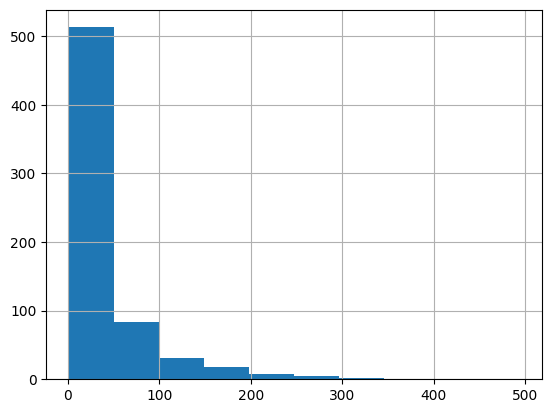

In [262]:
merged_author_bio_and_speech['Authorname'].value_counts().reset_index()['count'].hist()

In [274]:
df_education

,json,education,Date_of_birth,Bachelor_institution,Bachelor_year,PhD_institution,PhD_year,PhD_thesis_director,highest_level_of_study,Sources,has_PHD,date_cleaned
Alan Greenspan,"{ ""Date_of_birth"": ""March 6, 1926"", ""Bachelo...","{'Date_of_birth': 'March 6, 1926', 'Bachelor_i...","March 6, 1926",New York University,1948,New York University,1977,Arthur Burns,PhD in Economics,{'Date_of_birth': 'https://www.britannica.com/...,True,1926-03-06
Jean-Claude Trichet,"{ ""Date_of_birth"": ""1942-12-20"", ""Bachelor_i...","{'Date_of_birth': '1942-12-20', 'Bachelor_inst...",1942-12-20,École nationale supérieure des mines de Nancy,1964,NO_PHD,NO_PHD,NO_PHD,École nationale d'administration,{'Date_of_birth': 'https://en.wikipedia.org/wi...,False,1942-12-20
Amando M Tetangco,"{ ""Date_of_birth"": ""1952-11-14"", ""Bachelor_i...","{'Date_of_birth': '1952-11-14', 'Bachelor_inst...",1952-11-14,Ateneo de Manila University,,NO_PHD,NO_PHD,NO_PHD,Master's in Public Policy and Administration (...,{'Date_of_birth': 'https://en.wikipedia.org/wi...,False,1952-11-14
Gent Sejko,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,University of Tirana,1991,NO_PHD,NO_PHD,NO_PHD,Master's degree,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Ignazio Visco,"{ ""Date_of_birth"": ""1949-11-21"", ""Bachelor_i...","{'Date_of_birth': '1949-11-21', 'Bachelor_inst...",1949-11-21,Sapienza University of Rome,1971,University of Pennsylvania,1981,"Albert Ando, Lawrence R. Klein, and Roberto S....",PhD,{'Date_of_birth': 'https://en.wikipedia.org/wi...,True,1949-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...
Jlia illkov,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,NO_PHD,NO_PHD,NO_PHD,None,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Jiang Shun,"{ ""Date_of_birth"": None, ""Bachelor_instituti...","{'Date_of_birth': None, 'Bachelor_institution'...",None,None,None,NO_PHD,NO_PHD,NO_PHD,None,"{'Date_of_birth': None, 'Bachelor_institution'...",False,NaT
Jesimen Chipika,"{ ""Date_of_birth"": """", ""Bachelor_institution...","{'Date_of_birth': '', 'Bachelor_institution': ...",,University of Zimbabwe,,NO_PHD,NO_PHD,NO_PHD,Doctor of Philosophy in Economics,"{'Date_of_birth': '', 'Bachelor_institution': ...",False,NaT
Johan van den Heever,None,None,NaN,NaN,NaN,NO_PHD,NO_PHD,NO_PHD,NaN,NaN,False,NaT


In [257]:
df_education.loc['Amando M Tetangco']

json                      {  "Date_of_birth": "1952-11-14",  "Bachelor_i...
education                 {'Date_of_birth': '1952-11-14', 'Bachelor_inst...
Date_of_birth                                                    1952-11-14
Bachelor_institution                            Ateneo de Manila University
Bachelor_year                                                              
PhD_institution                                                      NO_PHD
PhD_year                                                             NO_PHD
PhD_thesis_director                                                  NO_PHD
highest_level_of_study    Master's in Public Policy and Administration (...
Sources                   {'Date_of_birth': 'https://en.wikipedia.org/wi...
has_PHD                                                               False
date_cleaned                                            1952-11-14 00:00:00
Name: Amando M Tetangco, dtype: object

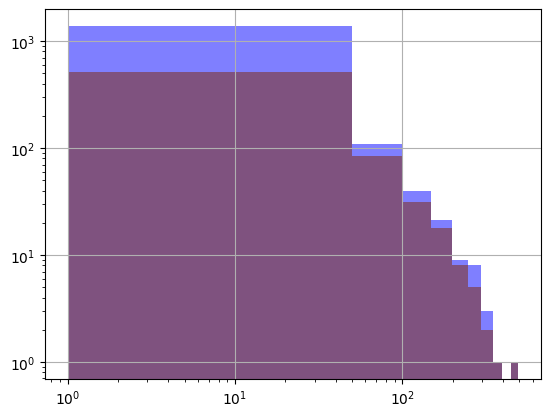

In [268]:
import matplotlib.pyplot as plt
merged_author_bio_and_speech['Authorname'].value_counts().reset_index()['count'].hist(label='Aggregated Data', color='orange')
df['Authorname'].value_counts().reset_index()['count'].hist(alpha=0.5, label='Original Data', color='blue')

plt.yscale('log')
plt.xscale('log')

In [269]:
# Count speeches for each speaker in both DataFrames
df_counts = df['Authorname'].value_counts()
merged_counts = merged_author_bio_and_speech['Authorname'].value_counts()

# Find the difference in counts
missing_speeches = df_counts.subtract(merged_counts, fill_value=0)

# Filter speakers with more than 10 missing speeches
speakers_with_missing = missing_speeches[missing_speeches > 10]

# Display the result
print(speakers_with_missing)

Authorname
Abdellatif Jouahri              57.0
Abdul Rasheed Ghaffour          14.0
Adam Posen                      15.0
Adnan Zaylani Mohamad Zahid     33.0
Ahmed Abdulkarim Alkholifey     24.0
                               ...  
Wu Xiaoling                     17.0
Yaga Venugopal Reddy           163.0
Yandraduth Googoolye            51.0
Zamani Abdul Ghani              20.0
ahap Kavcolu                    17.0
Name: count, Length: 221, dtype: float64


In [273]:
speakers_with_missing.reset_index().sort_values('count')

,Authorname,count
9,Alvin Tan,11.0
50,David Rule,11.0
125,Kishori J Udeshi,11.0
112,John Palmer,11.0
194,Stefan Gerlach,11.0
...,...,...
177,Rafael Buenaventura,203.0
22,Atiur Rahman,254.0
13,Andreas Dombret,267.0
183,Robert P Forrestal,283.0


In [275]:
df_education.loc['Amando M Tetangco']

json                      {  "Date_of_birth": "1952-11-14",  "Bachelor_i...
education                 {'Date_of_birth': '1952-11-14', 'Bachelor_inst...
Date_of_birth                                                    1952-11-14
Bachelor_institution                            Ateneo de Manila University
Bachelor_year                                                              
PhD_institution                                                      NO_PHD
PhD_year                                                             NO_PHD
PhD_thesis_director                                                  NO_PHD
highest_level_of_study    Master's in Public Policy and Administration (...
Sources                   {'Date_of_birth': 'https://en.wikipedia.org/wi...
has_PHD                                                               False
date_cleaned                                            1952-11-14 00:00:00
Name: Amando M Tetangco, dtype: object